In [740]:
#all packages needed 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import umap
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import joblib
import shap

#CNN modules
from tensorflow.keras.layers import Conv1D, MaxPooling1D
#setting seed for reproducibility
import random
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
set_seed(42)
scale=StandardScaler()

BEST Model: CNN+LSTM F1->68%

In [741]:
#importing the gridsearch table with the chosen parammeters

df_modelling=pd.read_parquet('../df_modelling.parquet')

In [742]:
numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings_window'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days'],
      dtype='object')


In [743]:
#function for creating sequences
def create_sequences(embeddings, numeric, target, sequence_length):
    X_emb_seq = []
    X_num_seq = []
    y_seq = []

    for i in range(sequence_length, len(embeddings)):
        X_emb_seq.append(embeddings[i-sequence_length:i])
        X_num_seq.append(numeric[i-sequence_length:i])
        y_seq.append(target[i])

    return (
        np.array(X_emb_seq),
        np.array(X_num_seq),
        np.array(y_seq)
    )

In [744]:
sequence_length = 20  # timesteps

#splitting data
embeddings_array = np.stack(df_modelling['embeddings_vector'])
numerical_values = np.stack(df_modelling[numerical_columns].values)
y = df_modelling['TargetVariable:Up/Down'].values


N = len(embeddings_array)
#train 70% val 20% test 10%
train_end = int(N * 0.7)
val_end = int(N * 0.9)

# Raw splits
emb_train_raw = embeddings_array[:train_end]
emb_val_raw = embeddings_array[train_end:val_end]
emb_test_raw = embeddings_array[val_end:]

num_train_raw = numerical_values[:train_end]
num_val_raw = numerical_values[train_end:val_end]
num_test_raw = numerical_values[val_end:]

y_train_raw = y[:train_end]
y_val_raw = y[train_end:val_end]
y_test_raw = y[val_end:]

num_train_raw = scale.fit_transform(num_train_raw)
num_val_raw = scale.transform(num_val_raw)
num_test_raw = scale.transform(num_test_raw)


In [745]:

#LSTM will look 20 steps in the past
X_emb_train, X_num_train, y_train = create_sequences(emb_train_raw, num_train_raw, y_train_raw, sequence_length)
X_emb_val, X_num_val, y_val = create_sequences(emb_val_raw, num_val_raw, y_val_raw, sequence_length)
X_emb_test, X_num_test, y_test = create_sequences(emb_test_raw, num_test_raw, y_test_raw, sequence_length)

In [746]:
model = load_model("best_model_CNN-LSTM.keras")

In [747]:
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0

#selecting best threshold on val data

y_prob = model.predict([X_emb_val, X_num_val])
for threshold in thresholds:
    y_pred_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_pred_tr, output_dict=True)
    f1_scores.append(report['macro avg']['f1-score'])

#deciding the best index    
f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#now deciding F1 on test data with the decided best threshold
y_prob = model.predict([X_emb_test, X_num_test])
y_pred_tr = (y_prob > threshold).astype(int)
report=classification_report(y_test, y_pred_tr, output_dict=True)
f1=report['macro avg']["f1-score"]
print(f"Best Result is f1 {f1} at threshold {threshold}")

/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_layer_10', 'input_layer_11']. Received: the structure of inputs=('*', '*')
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Best Result is f1 0.6836363636363636 at threshold 0.6000000000000001


/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
              precision    recall  f1-score   support

           0       0.67      0.62      0.64        13
           1       0.71      0.75      0.73        16

    accuracy                           0.69        29
   macro avg       0.69      0.68      0.68        29
weighted avg       0.69      0.69      0.69        29

confusion_matrix is:


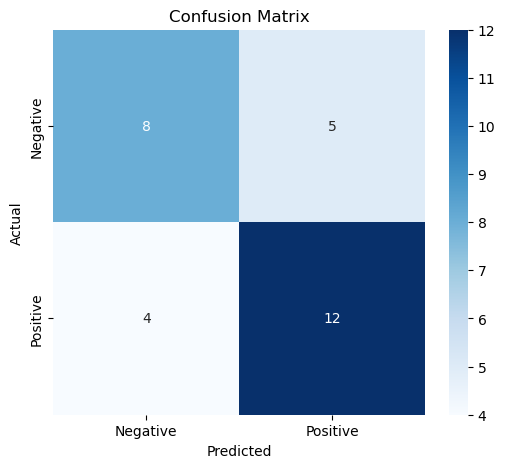

In [748]:
y_prob = model.predict([X_emb_test, X_num_test])
y_pred = (y_prob > threshold).astype(int)
print(classification_report(y_test, y_pred))

print("confusion_matrix is:")
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("Results/Confusion Matrix CNN-LSTM.png", bbox_inches='tight', transparent=True)
plt.show()

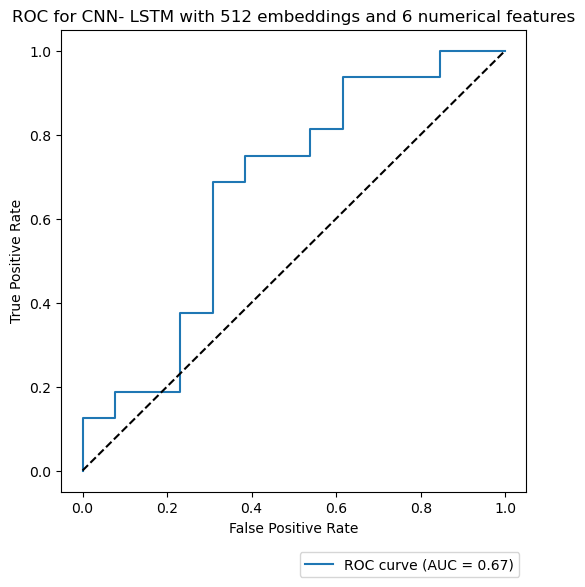

In [749]:
auc=roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
plt.title("ROC for CNN- LSTM with 512 embeddings and 6 numerical features")
plt.show()

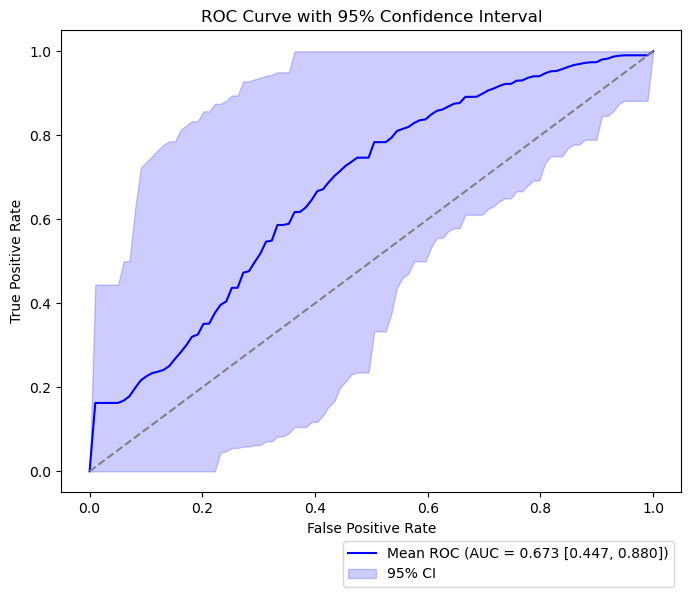

In [750]:
#confidence 
n_bootstraps = 1000
rng = np.random.RandomState(42)

# base ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# grid for interpolation
mean_fpr = np.linspace(0, 1, 100)

tprs = []
aucs = []

for i in range(n_bootstraps):
    indices = resample(range(len(y_test)), replace=True)
    
    # skip invalid samples
    if len(np.unique(y_test[indices])) < 2:
        continue
    
    y_true_sample = y_test[indices]
    y_scores_sample = y_prob[indices]
    
    fpr_i, tpr_i, _ = roc_curve(y_true_sample, y_scores_sample)
    auc_i = roc_auc_score(y_true_sample, y_scores_sample)
    
    # interpolate TPR onto common FPR grid
    tpr_interp = np.interp(mean_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    
    tprs.append(tpr_interp)
    aucs.append(auc_i)

# convert to arrays
tprs = np.array(tprs)
aucs = np.array(aucs)

# mean and CI
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.percentile(tprs, 97.5, axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)

mean_auc = aucs.mean()
auc_lower = np.percentile(aucs, 2.5)
auc_upper = np.percentile(aucs, 97.5)

# plot
plt.figure(figsize=(8, 6))

# mean ROC
plt.plot(mean_fpr, mean_tpr,
         label=f"Mean ROC (AUC = {mean_auc:.3f} [{auc_lower:.3f}, {auc_upper:.3f}])",
         color="blue")

# confidence band
plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color="blue", alpha=0.2,
                 label="95% CI")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with 95% Confidence Interval")
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.22), facecolor='none')
plt.savefig("Results/ROC curve CNN-LSTM.png", bbox_inches='tight', transparent=True)
plt.show()

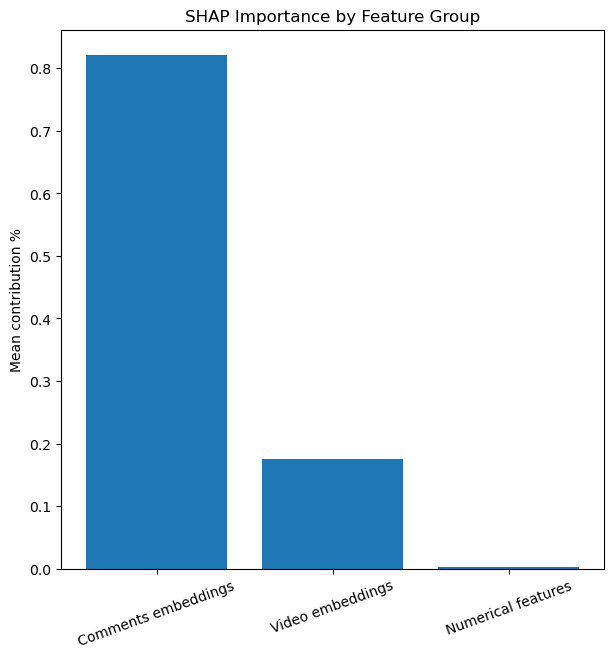

In [751]:
# Create SHAP explainer

# 1. background data with first 100 samples
background = [
    X_emb_train[:100],   
    X_num_train[:100]   
]
# 2. create DeepExplainer
explainer = shap.GradientExplainer(model, background)



# 3. compute SHAP values
shap_values = explainer.shap_values([
    X_emb_test,
    X_num_test
])

# 4. split model inputs
shap_emb = shap_values[0]   # embeddings branch
shap_num = shap_values[1]   # numerical branch

# 5. split embeddings into comment vs text
shap_comment = shap_emb[:, :, :256]
shap_text    = shap_emb[:, :, 256:]

# 6. aggregate over time + features (for interpretability)
comment_importance = np.abs(shap_comment).sum(axis=(1, 2))
text_importance    = np.abs(shap_text).sum(axis=(1, 2))
num_importance     = np.abs(shap_num).sum(axis=(1, 2))


#visualisation

labels = ["Comments embeddings", "Video embeddings", "Numerical features"]
total=(comment_importance.mean() + text_importance.mean() + num_importance.mean())

values = [
    comment_importance.mean()/total,
    text_importance.mean()/total,
    num_importance.mean()/total
]

plt.figure(figsize=(7,7))
plt.bar(labels, values)
plt.title("SHAP Importance by Feature Group")
plt.ylabel("Mean contribution %")
plt.xticks(rotation=20)
plt.savefig("Results/Feature Importance CNN-LSTM.png",transparent=True)
plt.show()

2nd Best Model -> LSTM F1 -> 61%

In [752]:

numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings_window'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days', 'embeddings_vector'],
      dtype='object')


In [753]:
#function for creating sequences
def create_sequences(embeddings, numeric, target, sequence_length):
    X_emb_seq = []
    X_num_seq = []
    y_seq = []

    for i in range(sequence_length, len(embeddings)):
        X_emb_seq.append(embeddings[i-sequence_length:i])
        X_num_seq.append(numeric[i-sequence_length:i])
        y_seq.append(target[i])

    return (
        np.array(X_emb_seq),
        np.array(X_num_seq),
        np.array(y_seq)
    )

In [754]:


sequence_length = 20  # timesteps


#splitting data
embeddings_array = np.stack(df_modelling['embeddings_vector'])
numerical_values = np.stack(df_modelling[numerical_columns].values)
y = df_modelling['TargetVariable:Up/Down'].values


N = len(embeddings_array)
#train 70% val 20% test 10%
train_end = int(N * 0.7)
val_end = int(N * 0.9)

# Raw splits
emb_train_raw = embeddings_array[:train_end]
emb_val_raw = embeddings_array[train_end:val_end]
emb_test_raw = embeddings_array[val_end:]

num_train_raw = numerical_values[:train_end]
num_val_raw = numerical_values[train_end:val_end]
num_test_raw = numerical_values[val_end:]

y_train_raw = y[:train_end]
y_val_raw = y[train_end:val_end]
y_test_raw = y[val_end:]

num_train_raw = scale.fit_transform(num_train_raw)
num_val_raw = scale.transform(num_val_raw)
num_test_raw = scale.transform(num_test_raw)


In [755]:

#LSTM will look 20 steps in the past
X_emb_train, X_num_train, y_train = create_sequences(emb_train_raw, num_train_raw, y_train_raw, sequence_length)
X_emb_val, X_num_val, y_val = create_sequences(emb_val_raw, num_val_raw, y_val_raw, sequence_length)
X_emb_test, X_num_test, y_test = create_sequences(emb_test_raw, num_test_raw, y_test_raw, sequence_length)

In [756]:
model = load_model("best_model_LSTM.keras")

In [757]:
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0

#selecting best threshold on val data

y_prob = model.predict([X_emb_val, X_num_val])
for threshold in thresholds:
    y_pred_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_pred_tr, output_dict=True)
    f1_scores.append(report['macro avg']['f1-score'])

#deciding the best index    
f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#now deciding F1 on test data with the decided best threshold
y_prob = model.predict([X_emb_test, X_num_test])
y_pred_tr = (y_prob > threshold).astype(int)
report=classification_report(y_test, y_pred_tr, output_dict=True)
f1=report['macro avg']['f1-score']
print(f"Best Result is f1 {f1} at threshold {threshold}")

/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_layer_6', 'input_layer_7']. Received: the structure of inputs=('*', '*')
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Best Result is f1 0.6133333333333333 at threshold 0.7000000000000001


/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
              precision    recall  f1-score   support

           0       0.55      0.85      0.67        13
           1       0.78      0.44      0.56        16

    accuracy                           0.62        29
   macro avg       0.66      0.64      0.61        29
weighted avg       0.68      0.62      0.61        29

confusion_matrix is:


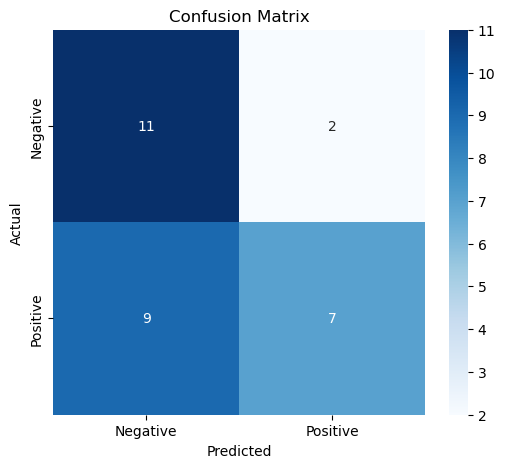

In [758]:
y_prob = model.predict([X_emb_test, X_num_test])
y_pred = (y_prob > threshold).astype(int)
print(classification_report(y_test, y_pred))

print("confusion_matrix is:")
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("Results/Confusion Matrix LSTM.png", transparent=True)
plt.show()

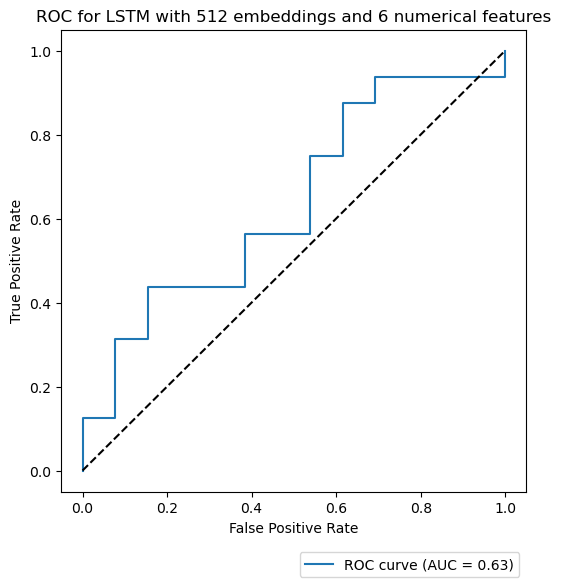

In [759]:
auc=roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.title("ROC for LSTM with 512 embeddings and 6 numerical features")
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
plt.show()

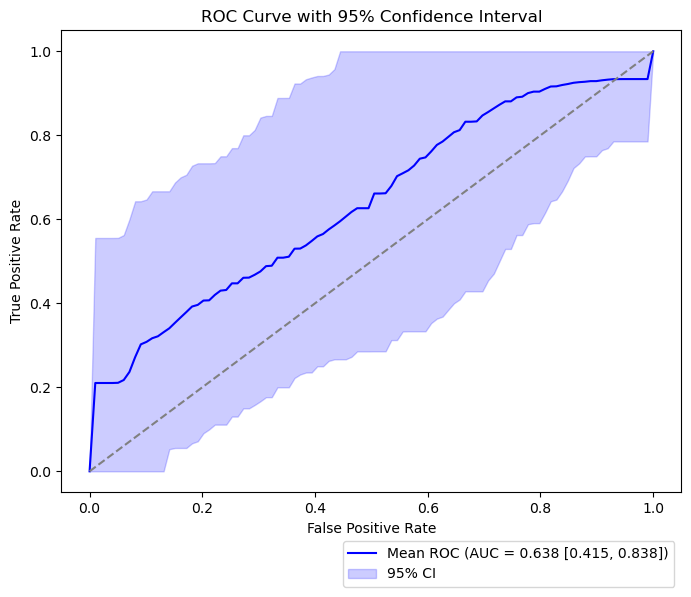

In [760]:
#confidence 
n_bootstraps = 1000
rng = np.random.RandomState(42)

# base ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# grid for interpolation
mean_fpr = np.linspace(0, 1, 100)

tprs = []
aucs = []

for i in range(n_bootstraps):
    indices = resample(range(len(y_test)), replace=True)
    
    # skip invalid samples
    if len(np.unique(y_test[indices])) < 2:
        continue
    
    y_true_sample = y_test[indices]
    y_scores_sample = y_prob[indices]
    
    fpr_i, tpr_i, _ = roc_curve(y_true_sample, y_scores_sample)
    auc_i = roc_auc_score(y_true_sample, y_scores_sample)
    
    # interpolate TPR onto common FPR grid
    tpr_interp = np.interp(mean_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    
    tprs.append(tpr_interp)
    aucs.append(auc_i)

# convert to arrays
tprs = np.array(tprs)
aucs = np.array(aucs)

# mean and CI
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.percentile(tprs, 97.5, axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)

mean_auc = aucs.mean()
auc_lower = np.percentile(aucs, 2.5)
auc_upper = np.percentile(aucs, 97.5)

# plot
plt.figure(figsize=(8, 6))

# mean ROC
plt.plot(mean_fpr, mean_tpr,
         label=f"Mean ROC (AUC = {mean_auc:.3f} [{auc_lower:.3f}, {auc_upper:.3f}])",
         color="blue")

# confidence band
plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color="blue", alpha=0.2,
                 label="95% CI")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with 95% Confidence Interval")
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.22), facecolor='none')
plt.savefig("Results/ROC curve LSTM.png", bbox_inches='tight', transparent=True)
plt.show()

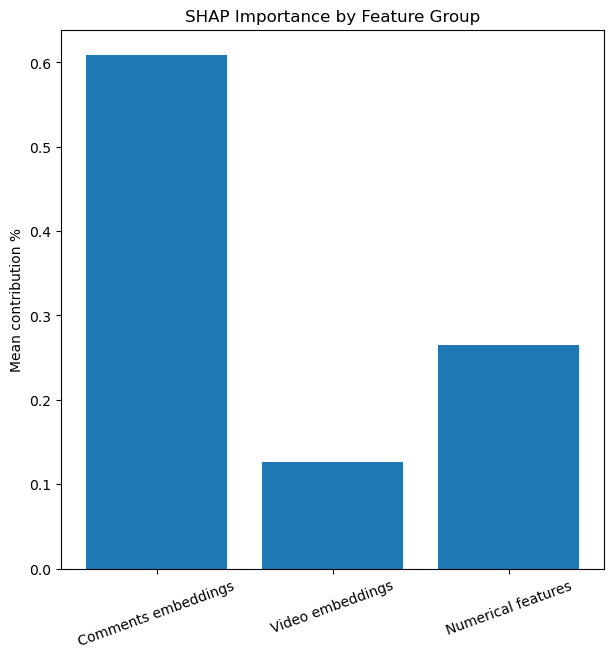

In [761]:
# Create SHAP explainer

# 1. background data with first 100 samples
background = [
    X_emb_train[:100],   
    X_num_train[:100]   
]
# 2. create DeepExplainer
explainer = shap.GradientExplainer(model, background)



# 3. compute SHAP values
shap_values = explainer.shap_values([
    X_emb_test,
    X_num_test
])

# 4. split model inputs
shap_emb = shap_values[0]   # embeddings branch
shap_num = shap_values[1]   # numerical branch

# 5. split embeddings into comment vs text
shap_comment = shap_emb[:, :, :256]
shap_text    = shap_emb[:, :, 256:]

# 6. aggregate over time + features (for interpretability)
comment_importance = np.abs(shap_comment).sum(axis=(1, 2))
text_importance    = np.abs(shap_text).sum(axis=(1, 2))
num_importance     = np.abs(shap_num).sum(axis=(1, 2))


#visualisation

labels = ["Comments embeddings", "Video embeddings", "Numerical features"]
total=(comment_importance.mean() + text_importance.mean() + num_importance.mean())

values = [
    comment_importance.mean()/total,
    text_importance.mean()/total,
    num_importance.mean()/total
]

plt.figure(figsize=(7,7))
plt.bar(labels, values)
plt.title("SHAP Importance by Feature Group")
plt.ylabel("Mean contribution %")
plt.xticks(rotation=20)
plt.savefig("Results/Feature Importance LSTM.png", transparent=True)
plt.show()

3rd Best Model - Baseline - Logistic Regression - F1: 57%

In [762]:
numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']
print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings_window'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days', 'embeddings_vector'],
      dtype='object')


In [763]:
x=df_modelling['embeddings_vector'][0]
print(f"Shape of the market vector {x.shape}")
numerical_values=np.stack(df_modelling[numerical_columns].values)
embeddings_values=np.stack(df_modelling['embeddings_vector'].values)
X =np.concatenate((numerical_values, embeddings_values), axis=1)

Shape of the market vector (512,)


In [764]:
#Load model
model=joblib.load("best_model_baseline_logistic_regression.joblib")

              precision    recall  f1-score   support

           0       0.51      0.60      0.55        43
           1       0.64      0.55      0.59        55

    accuracy                           0.57        98
   macro avg       0.57      0.58      0.57        98
weighted avg       0.58      0.57      0.57        98



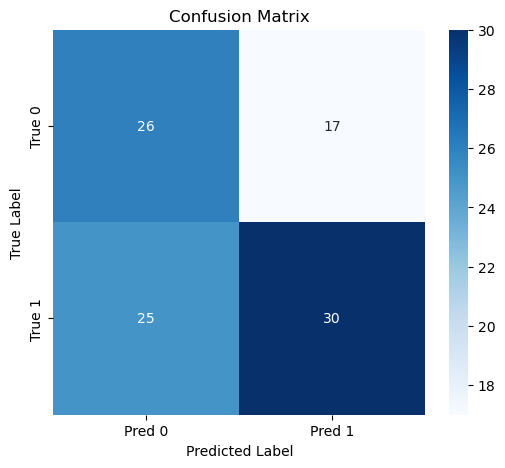

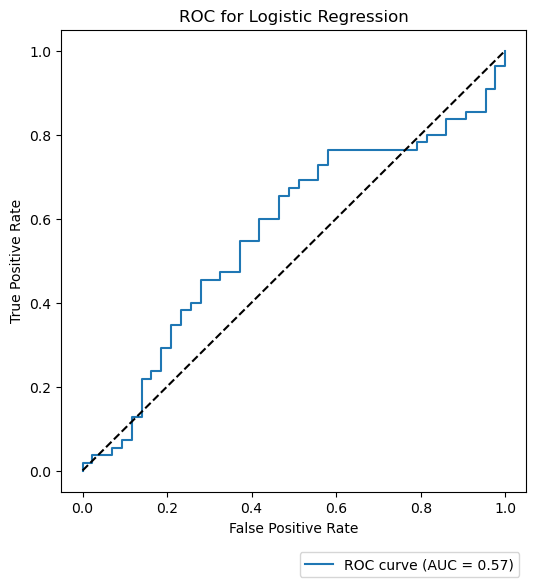

In [765]:
y = df_modelling['TargetVariable:Up/Down'].values

#scaling
X=scale.fit_transform(X)


#creating the splits for train & test
split_at=int(X.shape[0]*0.8)
X_train=X[:split_at]
X_test=X[split_at:]
y_train=y[:split_at]
y_test=y[split_at:]


#no need for outputing the model's coefficent because we have 500 columns
y_prob=model.predict_proba(X_test)[:,1]
y_pred=model.predict(X_test)
print(classification_report(y_test, y_pred))
auc=roc_auc_score(y_test, y_prob)

cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=["Pred 0", "Pred 1"],
yticklabels=["True 0", "True 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("Results/Confusion Matrix Baseline.png", bbox_inches='tight', transparent=True)
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
plt.title("ROC for Logistic Regression")

plt.show()

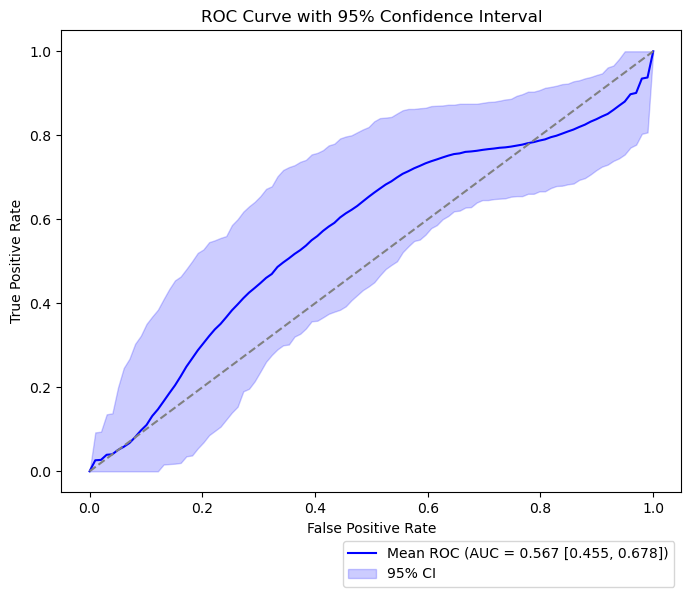

In [766]:
#confidence 
n_bootstraps = 1000
rng = np.random.RandomState(42)

# base ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# grid for interpolation
mean_fpr = np.linspace(0, 1, 100)

tprs = []
aucs = []

for i in range(n_bootstraps):
    indices = resample(range(len(y_test)), replace=True)
    
    # skip invalid samples
    if len(np.unique(y_test[indices])) < 2:
        continue
    
    y_true_sample = y_test[indices]
    y_scores_sample = y_prob[indices]
    
    fpr_i, tpr_i, _ = roc_curve(y_true_sample, y_scores_sample)
    auc_i = roc_auc_score(y_true_sample, y_scores_sample)
    
    # interpolate TPR onto common FPR grid
    tpr_interp = np.interp(mean_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    
    tprs.append(tpr_interp)
    aucs.append(auc_i)

# convert to arrays
tprs = np.array(tprs)
aucs = np.array(aucs)

# mean and CI
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.percentile(tprs, 97.5, axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)

mean_auc = aucs.mean()
auc_lower = np.percentile(aucs, 2.5)
auc_upper = np.percentile(aucs, 97.5)

# plot
plt.figure(figsize=(8, 6))

# mean ROC
plt.plot(mean_fpr, mean_tpr,
         label=f"Mean ROC (AUC = {mean_auc:.3f} [{auc_lower:.3f}, {auc_upper:.3f}])",
         color="blue")

# confidence band
plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color="blue", alpha=0.2,
                 label="95% CI")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with 95% Confidence Interval")
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.22), facecolor='none')
plt.savefig("Results/ROC curve Logistic Regression.png", bbox_inches='tight', transparent=True)

plt.show()

In [767]:
#feature importance of logistic regression

coef = model.coef_[0]  
coef_numerical=coef[:6]
comment_importance = np.abs(coef[-512:-256]).mean()
video_importance   = np.abs(coef[-256:]).mean()
features = df_modelling[numerical_columns].columns.to_list()
features.extend(["comment_importance", 'video_importance'])

importance = pd.DataFrame({
    "feature": features,
    "coefficient": np.concatenate([coef_numerical, [comment_importance], [video_importance]])
}).sort_values(by="coefficient", ascending=False)

print(importance)

                      feature  coefficient
6          comment_importance     0.359641
4       comment_sentiment_agg     0.303400
2  number_of_comments_at_date     0.149655
7            video_importance     0.096926
0       Closing Price($) lag1     0.095890
5            sentiment_tensor     0.007089
1    relative difference lag1    -0.228745
3           comment_likes_agg    -0.645518


4th Best Model LGBM -> F1: 46%

In [768]:
numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings_window'])), axis=1)



Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days', 'embeddings_vector'],
      dtype='object')


In [769]:
x=df_modelling['embeddings_vector'][0]
print(f"Shape of the market vector {x.shape}")

Shape of the market vector (512,)


In [770]:
#Defining X and y
y = df_modelling['TargetVariable:Up/Down'].values
numerical_values=np.stack(df_modelling[numerical_columns].values)
embeddings_values=np.stack(df_modelling['embeddings_vector'].values)
X =np.concatenate((numerical_values, embeddings_values), axis=1)

In [771]:
#scaling
X_scaled=scale.fit_transform(X)
X=X_scaled

In [772]:
#retrieveing best LGMB model
model=joblib.load("best_model_LGMB.joblib")

/Users/irtg/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and be

Best Result is f1 0.4638047138047138 at threshold 0.4
              precision    recall  f1-score   support

           0       0.38      0.45      0.41        20
           1       0.56      0.48      0.52        29

    accuracy                           0.47        49
   macro avg       0.47      0.47      0.46        49
weighted avg       0.48      0.47      0.47        49



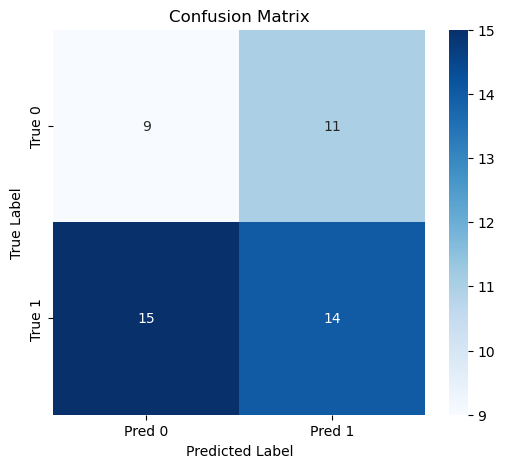

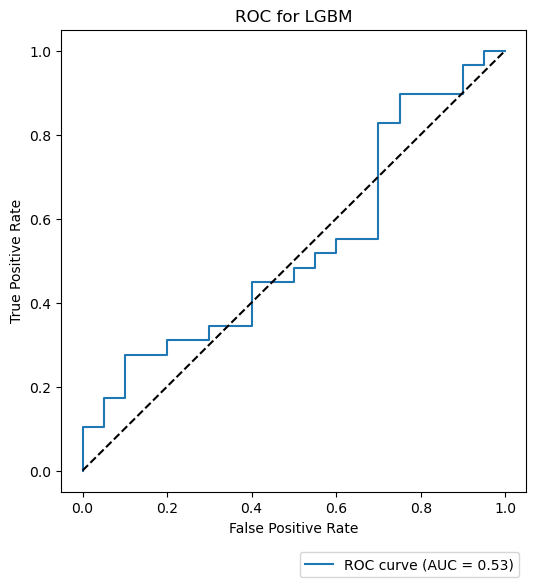

In [773]:
##creating the splits for train & test
split_at_train=int(X.shape[0]*0.7)
split_at_val=int(X.shape[0]*0.9)
X_train=X[:split_at_train]
X_val=X[split_at_train:split_at_val]
X_test=X[split_at_val:]
y_train=y[:split_at_train]
y_val=y[split_at_train:split_at_val]
y_test=y[split_at_val:]

#making out the best threshold
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0
best_report=None
#target performance score macro avg of f1_score 
y_prob = model.predict_proba(X_val)[:,1]
for threshold in thresholds:
    y_prob_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_prob_tr, output_dict=True)
    f1=report['macro avg']['f1-score']
    f1_scores.append(report['macro avg']['f1-score'])
    

f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#testing on test data
y_prob=model.predict_proba(X_test)[:,1]
y_pred=(y_prob > threshold).astype(int)

report=classification_report(y_test, y_pred, output_dict=True)
f1=report['macro avg']['f1-score']
print(f"Best Result is f1 {f1} at threshold {threshold}")
best_cm=confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
auc=roc_auc_score(y_test, y_prob)

cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=["Pred 0", "Pred 1"],
yticklabels=["True 0", "True 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("Results/Confusion Matrix LGBM.png", bbox_inches='tight', transparent=True)
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
plt.title("ROC for LGBM")

plt.show()

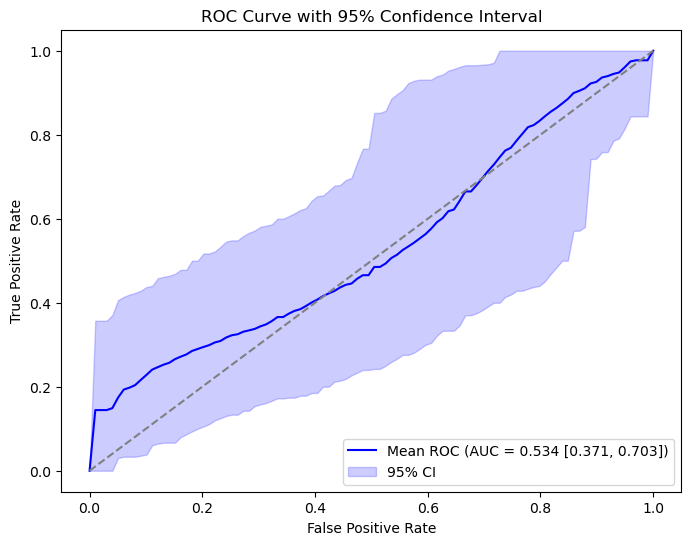

In [774]:
#confidence 
n_bootstraps = 1000
rng = np.random.RandomState(42)

# base ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# grid for interpolation
mean_fpr = np.linspace(0, 1, 100)

tprs = []
aucs = []

for i in range(n_bootstraps):
    indices = resample(range(len(y_test)), replace=True)
    
    # skip invalid samples
    if len(np.unique(y_test[indices])) < 2:
        continue
    
    y_true_sample = y_test[indices]
    y_scores_sample = y_prob[indices]
    
    fpr_i, tpr_i, _ = roc_curve(y_true_sample, y_scores_sample)
    auc_i = roc_auc_score(y_true_sample, y_scores_sample)
    
    # interpolate TPR onto common FPR grid
    tpr_interp = np.interp(mean_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    
    tprs.append(tpr_interp)
    aucs.append(auc_i)

# convert to arrays
tprs = np.array(tprs)
aucs = np.array(aucs)

# mean and CI
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.percentile(tprs, 97.5, axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)

mean_auc = aucs.mean()
auc_lower = np.percentile(aucs, 2.5)
auc_upper = np.percentile(aucs, 97.5)

# plot
plt.figure(figsize=(8, 6))

# mean ROC
plt.plot(mean_fpr, mean_tpr,
         label=f"Mean ROC (AUC = {mean_auc:.3f} [{auc_lower:.3f}, {auc_upper:.3f}])",
         color="blue")

# confidence band
plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color="blue", alpha=0.2,
                 label="95% CI")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with 95% Confidence Interval")
plt.legend(loc="lower right")
plt.savefig("Results/ROC curve LGBM.png", bbox_inches='tight', transparent=True)
plt.show()